In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("phucthaiv02/butterfly-image-classification")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Abhishek\.cache\kagglehub\datasets\phucthaiv02\butterfly-image-classification\versions\3


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread
import tensorflow as tf

C:\Users\Abhishek\tf-env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
train_path = "C:\\Users\\Abhishek\\.cache\\kagglehub\\datasets\\phucthaiv02\\butterfly-image-classification\\versions\\3\\train\\"
test_path = "C:\\Users\\Abhishek\\.cache\\kagglehub\\datasets\\phucthaiv02\\butterfly-image-classification\\versions\\3\\test\\"

In [4]:
train_df = pd.read_csv('Training_set.csv')
test_df = pd.read_csv('Testing_set.csv')

In [5]:
train_df

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART
...,...,...
6494,Image_6495.jpg,MANGROVE SKIPPER
6495,Image_6496.jpg,MOURNING CLOAK
6496,Image_6497.jpg,APPOLLO
6497,Image_6498.jpg,ELBOWED PIERROT


<Axes: xlabel='count', ylabel='label'>

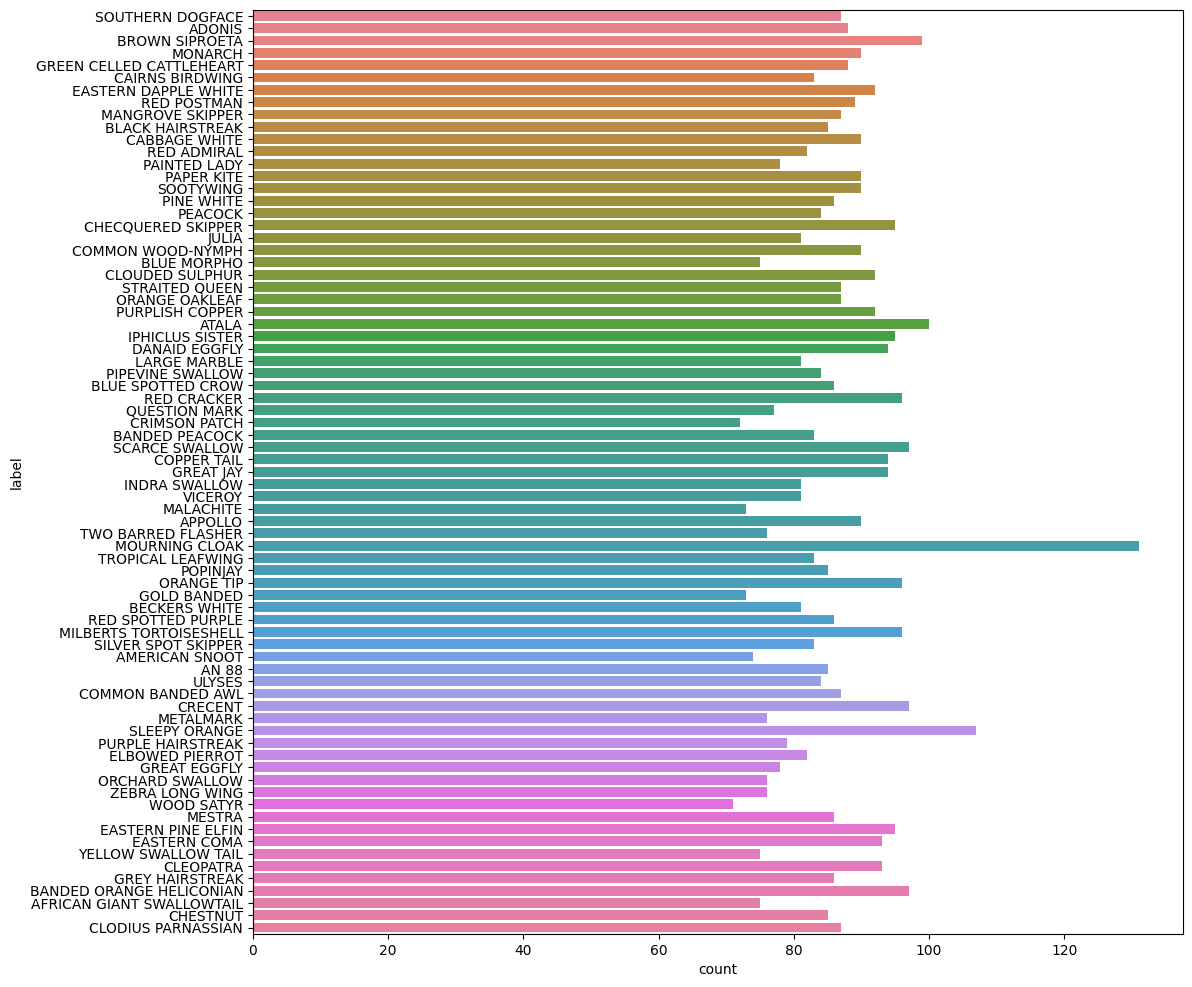

In [6]:
plt.figure(figsize=(12,12))
sns.countplot(data=train_df, y='label', hue = 'label')

In [7]:
test_df #no labels, kindoff useless

,filename
0,Image_1.jpg
1,Image_2.jpg
2,Image_3.jpg
3,Image_4.jpg
4,Image_5.jpg
...,...
2781,Image_2782.jpg
2782,Image_2783.jpg
2783,Image_2784.jpg
2784,Image_2785.jpg


In [8]:
import os

In [9]:
os.listdir(train_path)[0]

'Image_1.jpg'

In [10]:
len(os.listdir(train_path))

6499

In [11]:
img = imread(train_path+'Image_632.jpg')

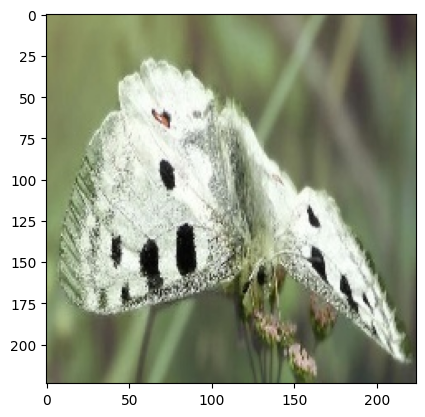

In [12]:
plt.imshow(img)

In [13]:
img.shape

(224, 224, 3)

In [14]:
# this shape is consistent for all images in this dataset

In [15]:
#have to associate the df to the image

In [16]:
224*224

50176

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [18]:
datagen = ImageDataGenerator( rotation_range=1, width_shift_range=0.3, height_shift_range=0.3, validation_split=0.2, rescale=1./255)

In [19]:
train_datagen = datagen.flow_from_dataframe(train_df, directory=train_path, y_col='label',target_size=(224,224), subset = 'training',save_format='jpg')

Found 5200 validated image filenames belonging to 75 classes.


In [20]:
val_datagen = datagen.flow_from_dataframe(train_df, directory=train_path, y_col='label',target_size=(224,224), subset = 'validation',save_format='jpg')

Found 1299 validated image filenames belonging to 75 classes.


In [21]:
label_class =[(v,k) for k,v in train_datagen.class_indices.items()]
label_class

[(0, 'ADONIS'),
 (1, 'AFRICAN GIANT SWALLOWTAIL'),
 (2, 'AMERICAN SNOOT'),
 (3, 'AN 88'),
 (4, 'APPOLLO'),
 (5, 'ATALA'),
 (6, 'BANDED ORANGE HELICONIAN'),
 (7, 'BANDED PEACOCK'),
 (8, 'BECKERS WHITE'),
 (9, 'BLACK HAIRSTREAK'),
 (10, 'BLUE MORPHO'),
 (11, 'BLUE SPOTTED CROW'),
 (12, 'BROWN SIPROETA'),
 (13, 'CABBAGE WHITE'),
 (14, 'CAIRNS BIRDWING'),
 (15, 'CHECQUERED SKIPPER'),
 (16, 'CHESTNUT'),
 (17, 'CLEOPATRA'),
 (18, 'CLODIUS PARNASSIAN'),
 (19, 'CLOUDED SULPHUR'),
 (20, 'COMMON BANDED AWL'),
 (21, 'COMMON WOOD-NYMPH'),
 (22, 'COPPER TAIL'),
 (23, 'CRECENT'),
 (24, 'CRIMSON PATCH'),
 (25, 'DANAID EGGFLY'),
 (26, 'EASTERN COMA'),
 (27, 'EASTERN DAPPLE WHITE'),
 (28, 'EASTERN PINE ELFIN'),
 (29, 'ELBOWED PIERROT'),
 (30, 'GOLD BANDED'),
 (31, 'GREAT EGGFLY'),
 (32, 'GREAT JAY'),
 (33, 'GREEN CELLED CATTLEHEART'),
 (34, 'GREY HAIRSTREAK'),
 (35, 'INDRA SWALLOW'),
 (36, 'IPHICLUS SISTER'),
 (37, 'JULIA'),
 (38, 'LARGE MARBLE'),
 (39, 'MALACHITE'),
 (40, 'MANGROVE SKIPPER'),
 (41, 'M

This one is called : 
 COMMON BANDED AWL



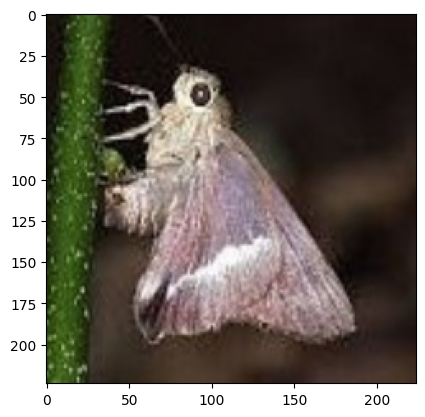

In [22]:
random = np.random.randint(5200)

path = train_datagen.filepaths[random]
plt.imshow(imread(path))
label = train_datagen.classes[random]
print(f'This one is called : \n {label_class[label][1]}\n')

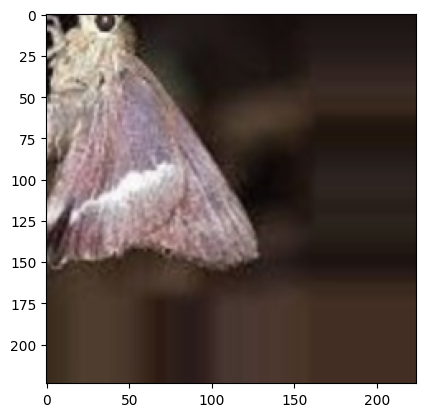

In [23]:
plt.imshow(datagen.random_transform(imread(path)))

In [24]:
#model now

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Input, MaxPool2D, GlobalAveragePooling2D, BatchNormalization, Activation, Dropout, Flatten

In [26]:
224*224

50176

In [27]:
image_classifier = Sequential()

image_classifier.add(Input(shape=[224,224,3]))
image_classifier.add(Conv2D(filters=32, kernel_size=(3,3), padding='same'))
image_classifier.add(BatchNormalization())
image_classifier.add(Activation('relu'))
image_classifier.add(MaxPool2D(pool_size=(2,2)))

image_classifier.add(Conv2D(filters=64, kernel_size=(3,3), padding='same'))
image_classifier.add(BatchNormalization())
image_classifier.add(Activation('relu'))
image_classifier.add(MaxPool2D(pool_size=(2,2)))

image_classifier.add(Conv2D(filters=128, kernel_size=(3,3), padding='same'))
image_classifier.add(BatchNormalization())
image_classifier.add(Activation('relu'))
image_classifier.add(MaxPool2D(pool_size=(2,2)))

image_classifier.add(Conv2D(filters=256, kernel_size=(3,3), padding='same'))
image_classifier.add(BatchNormalization())
image_classifier.add(Activation('relu'))
image_classifier.add(MaxPool2D(pool_size=(2,2)))

image_classifier.add(GlobalAveragePooling2D())
image_classifier.add(Dropout(0.25))
image_classifier.add(Dense(256, activation='relu'))
image_classifier.add(Dropout(0.25))
image_classifier.add(Dense(128, activation='relu'))
image_classifier.add(Dense(75, activation='softmax'))


image_classifier.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [28]:
image_classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 224, 224, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          65,7

 Total params: 498,699 (1.90 MB)

 Trainable params: 497,739 (1.90 MB)

 Non-trainable params: 960 (3.75 KB)

In [29]:
from tensorflow.keras.callbacks import EarlyStopping

In [30]:
early_stop=EarlyStopping(mode='min', patience = 15, restore_best_weights=True)

In [ ]:
image_classifier.fit(train_datagen, validation_data=val_datagen, epochs=2000, callbacks=[early_stop])

Epoch 1/2000
 41/163 ━━━━━━━━━━━━━━━━━━━━ 1:23 683ms/step - accuracy: 0.0256 - loss: 4.4037

In [ ]:
metrics = pd.DataFrame(image_classifier.history.history)

In [ ]:
metrics[['accuracy', 'val_accuracy']].plot()

In [ ]:
metrics[['loss', 'val_loss']].plot()

In [ ]:
image_classifier.evaluate(val_datagen)

In [ ]:
x_list=[]
y_list = []
for i in range(len(val_datagen)):    
    xbatch, ybatch = next(val_datagen)
    y_list.append(ybatch)
    x_list.append(xbatch)

In [ ]:
xseq = np.concatenate(x_list, axis=0)

In [ ]:
xseq.shape

In [ ]:
pred = image_classifier.predict(xseq)

In [ ]:
pred = np.argmax(pred, axis = -1)

In [ ]:
pred

In [ ]:
y_true =np.argmax(np.concatenate(y_list, axis = 0), axis=1)
y_true

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
sns.heatmap(confusion_matrix(y_true, pred))

In [ ]:
print(classification_report(y_true,pred))

In [ ]:
# beginning transfer learning

In [ ]:
train_datagen.batch_size

In [ ]:
val_datagen.image_shape

In [ ]:
from tensorflow.keras.applications import EfficientNetV2B0

In [ ]:
transfer = EfficientNetV2B0(include_top=False, weights= 'imagenet' , input_shape=[224,224,3], include_preprocessing=False)

In [ ]:
transfer.trainable = False

In [ ]:
# using functional api, instead of sequential

In [ ]:
x = transfer.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.25)(x)
x = Dense(128, activation='relu')(x)
output= Dense(75, activation='softmax')(x)

In [ ]:
from tensorflow.keras import Model

In [ ]:
transfer_model = Model(inputs=transfer.input, outputs = output )

In [ ]:
transfer_model.summary()

In [ ]:
early_stop=EarlyStopping(mode='min', patience = 15, restore_best_weights=True)

In [ ]:
transfer_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics=['accuracy'])

In [ ]:
transfer_model.fit(train_datagen,validation_data=val_datagen, epochs = 2000, callbacks=[early_stop] )

In [ ]:
metrics = pd.DataFrame(transfer_model.history.history)

In [ ]:
metrics[['accuracy', 'val_accuracy']].plot()

In [ ]:
metrics[['loss', 'val_loss']].plot()

In [ ]:
transfer_model.evaluate(val_datagen)

In [ ]:
x_list=[]
y_list = []
for i in range(len(val_datagen)):    
    xbatch, ybatch = next(val_datagen)
    y_list.append(ybatch)
    x_list.append(xbatch)

In [ ]:
xseq = np.concatenate(x_list, axis=0)
yseq = np.concatenate(y_list, axis=0)

In [ ]:
pred = transfer_model.predict(xseq)

In [ ]:
pred = np.argmax(pred, axis=-1)
y_true = np.argmax(yseq, axis=-1)

In [ ]:
pred

In [ ]:
y_true

In [ ]:
sns.heatmap(confusion_matrix(y_true, pred))

In [ ]:
print(classification_report(y_true, pred))

In [ ]:
#now only the autoencoder remains, lets do a simple one

In [ ]:
auto_train_datagen = datagen.flow_from_dataframe(train_df, directory=train_path, y_col=None,target_size=(224,224), subset = 'training',save_format='jpg', class_mode='input')

In [ ]:
auto_val_datagen = datagen.flow_from_dataframe(train_df, directory=train_path, y_col=None,target_size=(224,224), subset = 'validation',save_format='jpg', class_mode='input')

In [ ]:
from tensorflow.keras.layers import Reshape, Conv2DTranspose

In [ ]:
encoder = Sequential()
encoder.add(Input([224,224,3]))
encoder.add(Conv2D(32,3,padding='same', activation='relu'))
encoder.add(MaxPool2D())
encoder.add(Conv2D(64,3,padding='same', activation='relu'))
encoder.add(MaxPool2D())
encoder.add(Conv2D(128,3,padding='same', activation='relu'))
encoder.add(MaxPool2D())
encoder.add(Conv2D(256,3,padding='same', activation='relu'))
encoder.add(MaxPool2D())

In [ ]:
decoder = Sequential()
decoder.add(Input([14,14,256]))
decoder.add(Conv2DTranspose(128,3,strides=2, padding='same', activation='relu'))
decoder.add(Conv2DTranspose(64,3,strides=2, padding='same', activation='relu'))
decoder.add(Conv2DTranspose(32,3,strides=2, padding='same', activation='relu'))
decoder.add(Conv2DTranspose(3,3,strides=2, padding='same', activation='sigmoid'))


In [ ]:
decoder.summary()

In [ ]:
autoencoder = Sequential([encoder, decoder])

In [ ]:
autoencoder.summary()

In [ ]:
autoencoder.compile(optimizer='adam',loss='mse')

In [ ]:
autoencoder.fit(auto_train_datagen, validation_data=auto_val_datagen, epochs=2000, callbacks=[early_stop], batch_size=8)

In [ ]:
#interrupted to check, no valuable gains

In [ ]:
xbatch,_ = next(auto_val_datagen)

In [ ]:
print('original image\n\n')
plt.imshow(xbatch[5])
plt.show()

In [ ]:
len(xbatch)

In [ ]:
pred = autoencoder.predict(xbatch)

In [ ]:
n = np.random.randint(0,32)
plt.imshow(xbatch[n])

In [ ]:
plt.imshow(pred[n])

In [ ]:
# turning noise into images, simple gaussian

In [ ]:
z_noise = np.random.normal(size=(20,) + (14,14,256)).astype("float32")

In [ ]:
z_noise[0]

In [ ]:
z_pred= decoder.predict(z_noise)

In [ ]:
plt.imshow(z_pred[4])

In [ ]:
#thus decoder can only givce this pattern, not a butterfly due to improper latent vectors

In [ ]:
#we require a cvae based model to actually get latent vectors for a proper output

In [ ]:
# this is too complex at this point and thus we skip it

In [ ]:
#only dense based latent vector model we shall try

In [ ]:
encoder.summary()

In [ ]:
zin = Sequential()
zin.add(Input([256,]))
zin.add(Dense(14*14*256, activation='relu'))
zin.add(Reshape([14,14,256]))

In [ ]:
generator = Sequential([zin, decoder])

In [ ]:
generator.summary()

In [ ]:
noise_decode = np.random.normal(size=(20,) + (14,14,256)).astype("float32")

In [ ]:
pred_decode = decoder.predict(noise_decode)

In [ ]:
plt.imshow(pred_decode[0])

In [ ]:
noise_gen = np.random.normal(size=(32,256)).astype("float32")

In [ ]:
pred_gen = generator.predict(noise_gen)

In [ ]:
plt.imshow(pred_gen[10])

In [ ]:
#it does not work as imagined, but thats to be expected